# Import libraries for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine learning (sklearn)

In [3]:
#Import Required Libraries
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Dataset Description
- This dataset contains information about individuals and their medical insurance costs.
- Each row represents a client, and the columns describe their characteristics.

In [5]:
#Load and Explore Dataset
# Load dataset
df = pd.read_csv('C:\Datasets\insurance.csv')

# View first rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains information about individuals and their medical insurance charges.
The goal is to predict insurance charges based on other variables.
# Columns Explanation:
**age**: Age of the individual  
**sex**: Gender (male/female)  
**bmi**: Body Mass Index  
**children**: Number of dependents  
**smoker**: Smoking status (yes/no)  
**region**: Residential area  
**charges**: Medical insurance cost (target variable) 

In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Observation of the Dataset
**Number of records**: 1338  
**Missing data**: No missing values  
## Data types:  
**Numerical**: age, bmi, children, charges  
**Categorical**: sex, smoker, region

# Visual Observations

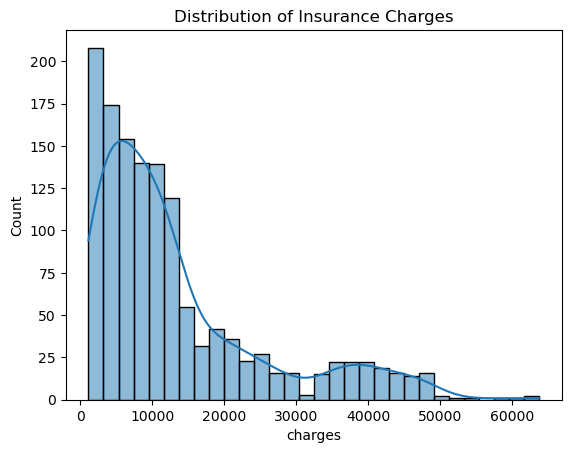

In [6]:
#Distribution of Charges
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Insurance Charges")
plt.show()

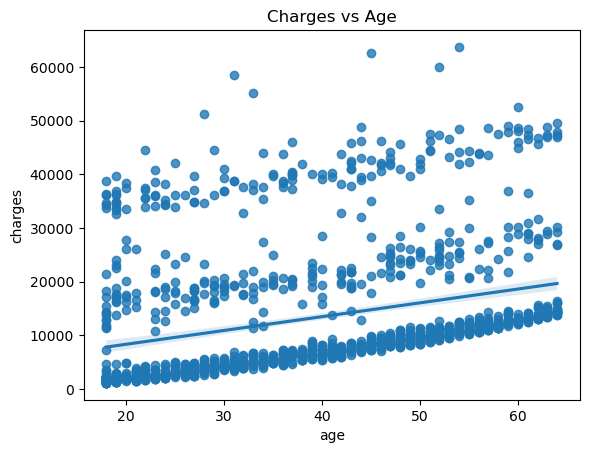

In [7]:
#Charges vs Age
sns.regplot(x='age', y='charges', data=df)
plt.title("Charges vs Age")
plt.show()

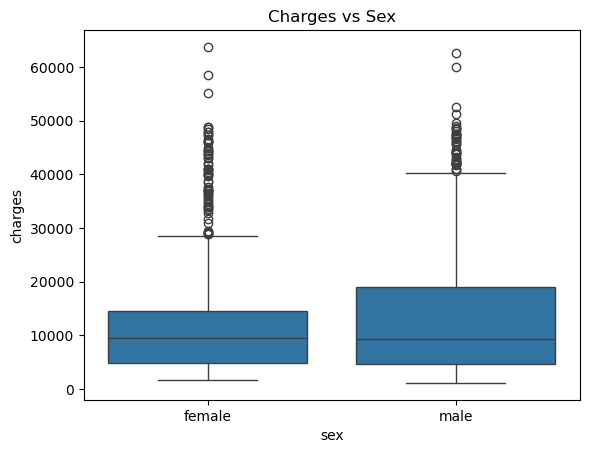

In [8]:
#Charges vs Sex
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Charges vs Sex")
plt.show()

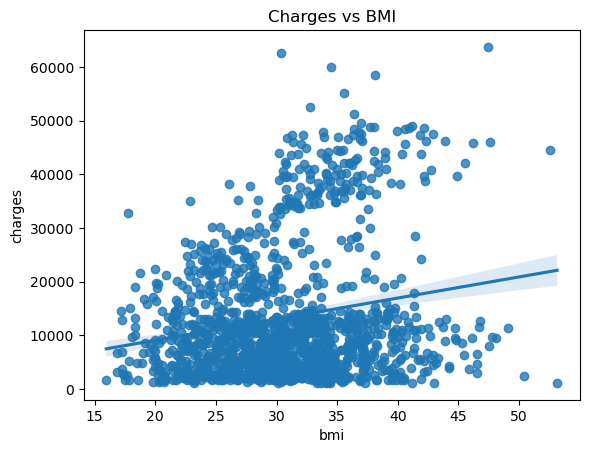

In [9]:
#Charges vs BMI
sns.regplot(x='bmi', y='charges', data=df)
plt.title("Charges vs BMI")
plt.show()

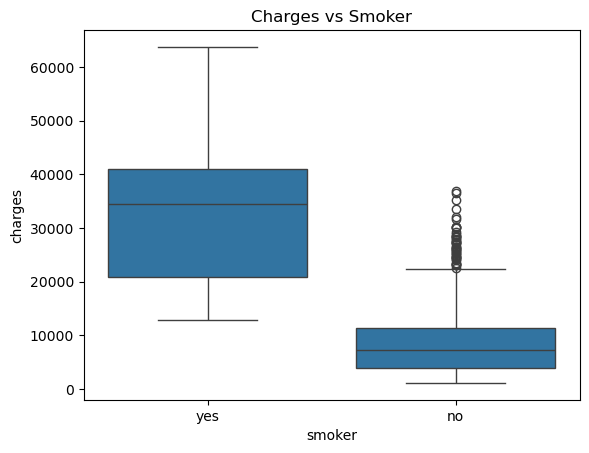

In [20]:
#Charges vs Smoker
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges vs Smoker")
plt.show()

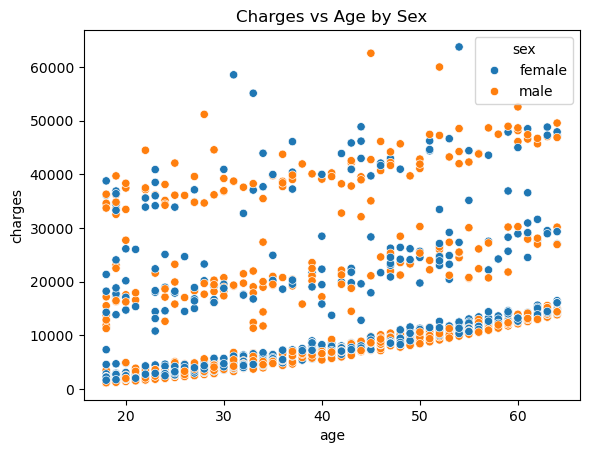

In [12]:
#Charges vs Age & Sex

# Interpretation
- Smoking has the strongest impact on charges (very high costs)
- Age shows a positive correlation (older → higher cost)
- BMI moderately affects charges
- Sex shows less impact

In [13]:
#Data Preprocessing
# Convert categorical variables into dummy variables
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


# Explanation

Since machine learning require numerical values for input, categorical features such as sex, smoker, and region must be converted to numerical values.

In [14]:
#Define Features & Target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [15]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#rain Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
#Make Predictions
y_pred = model.predict(X_test)

In [18]:
#Evaluate Model
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 4181.19447375365
MSE: 33596915.851361446
RMSE: 5796.284659276272
R2 Score: 0.7835929767120724


# Explanation
**MAE**: Average error  
**MSE**: Mean squared error  
**RMSE**: Penalizes large errors  
**R² Score**: How well model explains variance (closer to 1 = better)

# Reflection
1. Which variables most strongly influence charges?
    - Smoking status is the strongest predictor, followed by age and BMI.
2. Why might smoking affect insurance costs?
    - Smokers are more likely to develop serious health conditions, leading to higher medical expenses.
3. What improvements could be made to the model?
    - Use advanced models (e.g., Random Forest)
    - Handle outliers
    - Normalize data
    - Cross-validation